In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import TensorDataset, DataLoader
import gpytorch
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import load_cmapss_data
from src.utils.metrics import phm_scoring_function
from src.models.train_dkl_svgp import train_dkl_autoencoder

# graphic settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cpu


In [9]:
from sklearn.metrics import mean_absolute_error, r2_score
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

def compare_cmapss_dataset(dataset_name, dkl_epochs=30):
    print(f"\n\n{'='*60}")
    print(f"🚀 INIZIO VALUTAZIONE DATASET: {dataset_name}")
    print(f"{'='*60}")

    # 1. Load data
    df_train = load_cmapss_data(str(DATA_DIR / f'train_{dataset_name}.txt'))
    df_test = load_cmapss_data(str(DATA_DIR / f'test_{dataset_name}.txt'), str(DATA_DIR / f'RUL_{dataset_name}.txt'))

    # 2. Feature Selection (Settings + Sensors)
    candidate_cols = ['setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    # Variance calculation
    variances = df_train[candidate_cols].var()
    
    # Delete columns with zero variance (completely flat)
    dead_cols = variances[variances == 0.0].index.tolist()
    features = [c for c in candidate_cols if c not in dead_cols]
    
    print(f"Excluded columns (Zero Variance): {dead_cols if dead_cols else 'None'}")
    print(f"Active features (Settings + Sensors): {len(features)}")


    # 3. RUL Clipping
    MAX_RUL = 125
    df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)
    y_train = df_train['RUL'].values
    y_test_true = df_test['RUL'].values 

    # 4. Standardization (Fit on train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df_train[features].values)
    X_test_scaled = scaler.transform(df_test[features].values)

    # 5. Extracting Last Cycles (Standard NASA for fair metrics)
    last_cycle_indices = df_test.groupby('unit_nr').tail(1).index
    X_test_last = X_test_scaled[last_cycle_indices]
    y_test_last = y_test_true[last_cycle_indices]

    # --- RANDOM FOREST ---
    print("🌲 Training Baseline (Random Forest)...")
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_scaled, y_train)

    rf_preds_last = rf_model.predict(X_test_last)
    
    # Metrics RF
    rf_rmse = np.sqrt(mean_squared_error(y_test_last, rf_preds_last))
    rf_mae = mean_absolute_error(y_test_last, rf_preds_last)
    rf_r2 = r2_score(y_test_last, rf_preds_last)
    rf_score = phm_scoring_function(rf_preds_last, y_test_last)
    
    rf_errors = rf_preds_last - y_test_last
    rf_late_count = np.sum(rf_errors > 0)
    rf_early_count = np.sum(rf_errors < 0)

    rf_preds_all = rf_model.predict(X_test_scaled)

    # --- DKL + SVGP ---
    print(f"🧠 Training Proposed Model (DKL+SVGP - {dkl_epochs} epoche)...")
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    dkl_model, likelihood = train_dkl_autoencoder(
        train_loader=train_loader,
        input_dim=len(features),
        latent_dim=8,
        num_inducing=500,
        epochs=dkl_epochs,
        encoder_lr=1e-4,
        decoder_lr=1e-4,
        gp_lr=1e-2,
        lambda_recon=0.1,
        seed=42
    )

    dkl_model.eval()
    likelihood.eval()

    X_test_last_tensor = torch.tensor(X_test_last, dtype=torch.float32).to(device)
    X_test_all_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_dist_last = likelihood(dkl_model(X_test_last_tensor))
        dkl_preds_last = pred_dist_last.mean.cpu().numpy()
        
        # Metriche DKL
        dkl_rmse = np.sqrt(mean_squared_error(y_test_last, dkl_preds_last))
        dkl_mae = mean_absolute_error(y_test_last, dkl_preds_last)
        dkl_r2 = r2_score(y_test_last, dkl_preds_last)
        dkl_score = phm_scoring_function(dkl_preds_last, y_test_last)
        
        dkl_errors = dkl_preds_last - y_test_last
        dkl_late_count = np.sum(dkl_errors > 0)
        dkl_early_count = np.sum(dkl_errors < 0)

        pred_dist_all = likelihood(dkl_model(X_test_all_tensor))
        dkl_preds_all = pred_dist_all.mean.cpu().numpy()
        lower_all, upper_all = pred_dist_all.confidence_region()
        dkl_lower_all = lower_all.cpu().numpy()
        dkl_upper_all = upper_all.cpu().numpy()

    print("\n📊 --- REPORT METRICHE FINALI ---")
    print(f"{'Metrica':<20} | {'Random Forest':<15} | {'DKL+SVGP':<15}")
    print("-" * 55)
    print(f"{'RMSE (Cicli)':<20} | {rf_rmse:<15.2f} | {dkl_rmse:<15.2f}")
    print(f"{'MAE (Cicli)':<20} | {rf_mae:<15.2f} | {dkl_mae:<15.2f}")
    print(f"{'R-Squared (R2)':<20} | {rf_r2:<15.3f} | {dkl_r2:<15.3f}")
    print(f"{'C-MAPSS Score':<20} | {rf_score:<15.0f} | {dkl_score:<15.0f}")
    print(f"{'Late Preds (Guasti)':<20} | {rf_late_count:<15} | {dkl_late_count:<15}")
    print(f"{'Early Preds (Sicuri)':<20} | {rf_early_count:<15} | {dkl_early_count:<15}")
    print("-" * 55)

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_score = fig.add_subplot(gs[0, 1])
    ax_traj = fig.add_subplot(gs[1, :]) 

    models_labels = ['Baseline\n(Random Forest)', 'Proposed\n(DKL + SVGP)']
    palette = ['#8c564b', '#1f77b4']

    # Plot 1: RMSE Barplot
    sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
    ax_rmse.set_title(f'[{dataset_name}] RMSE on Final Cycle', fontsize=14, fontweight='bold')
    ax_rmse.set_ylabel('RMSE (Cycles)')
    for i, v in enumerate([rf_rmse, dkl_rmse]):
        ax_rmse.text(i, v + (max(rf_rmse, dkl_rmse)*0.02), f"{v:.2f}", ha='center', fontsize=12)

    # Plot 2: Score Barplot
    sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)
    ax_score.set_title(f'[{dataset_name}] C-MAPSS Score on Final Cycle', fontsize=14, fontweight='bold')
    ax_score.set_ylabel('Penalty Score')
    for i, v in enumerate([rf_score, dkl_score]):
        ax_score.text(i, v + (max(rf_score, dkl_score)*0.02), f"{v:,.0f}", ha='center', fontsize=12)

    # Plot 3: Trajectory of Engine
    first_engine_id = df_test['unit_nr'].unique()[0]
    eng_indices = df_test[df_test['unit_nr'] == first_engine_id].index
    y_true_eng = y_test_true[eng_indices]
    cycles = range(len(y_true_eng))

    ax_traj.plot(cycles, y_true_eng, label='True RUL', color='black', linewidth=3)
    ax_traj.plot(cycles, rf_preds_all[eng_indices], label='Random Forest Mean', color='#8c564b', linestyle='-.', linewidth=2.5)
    ax_traj.plot(cycles, dkl_preds_all[eng_indices], label='DKL+SVGP Mean', color='#1f77b4', linestyle='--', linewidth=2.5)
    ax_traj.fill_between(cycles, dkl_lower_all[eng_indices], dkl_upper_all[eng_indices], color='#1f77b4', alpha=0.2, label='DKL+SVGP (95% CI)')

    ax_traj.set_title(f'[{dataset_name}] Prediction Trajectories - Test Engine #{first_engine_id}', fontsize=16, fontweight='bold', pad=15)
    ax_traj.set_xlabel('Operational Cycle', fontsize=12)
    ax_traj.set_ylabel('Remaining Useful Life (RUL)', fontsize=12)
    ax_traj.legend(fontsize=12, loc='upper right')
    ax_traj.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {'rf_rmse': rf_rmse, 'dkl_rmse': dkl_rmse, 'rf_score': rf_score, 'dkl_score': dkl_score}



🚀 INIZIO VALUTAZIONE DATASET: FD001
Excluded columns (Zero Variance): ['setting_3', 's_1', 's_10', 's_18', 's_19']
Active features (Settings + Sensors): 19
🌲 Training Baseline (Random Forest)...
🧠 Training Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | ELBO Loss: 329300.8902 | Recon Loss: 0.7848
Epoch 02 | ELBO Loss: 49666.3977 | Recon Loss: 0.5078
Epoch 03 | ELBO Loss: 21498.2582 | Recon Loss: 0.4399
Epoch 04 | ELBO Loss: 18894.2469 | Recon Loss: 0.4014
Epoch 05 | ELBO Loss: 17798.9206 | Recon Loss: 0.3710
Epoch 06 | ELBO Loss: 17021.3165 | Recon Loss: 0.3514
Epoch 07 | ELBO Loss: 16459.9899 | Recon Loss: 0.3386
Epoch 08 | ELBO Loss: 16056.1771 | Recon Loss: 0.3283
Epoch 09 | ELBO Loss: 15404.4591 | Recon Loss: 0.3192
Epoch 10 | ELBO Loss: 15245.9310 | Recon Loss: 0.3126
Epoch 11 | ELBO Loss: 14843.3705 | Recon Loss: 0.3051
Epoch 12 | ELBO Loss: 14433.3033 | Recon Loss: 0.2993
Epoch 13 | ELBO Loss: 14135.4023 | Recon 

/tmp/ipykernel_3981/2356209643.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
/tmp/ipykernel_3981/2356209643.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)


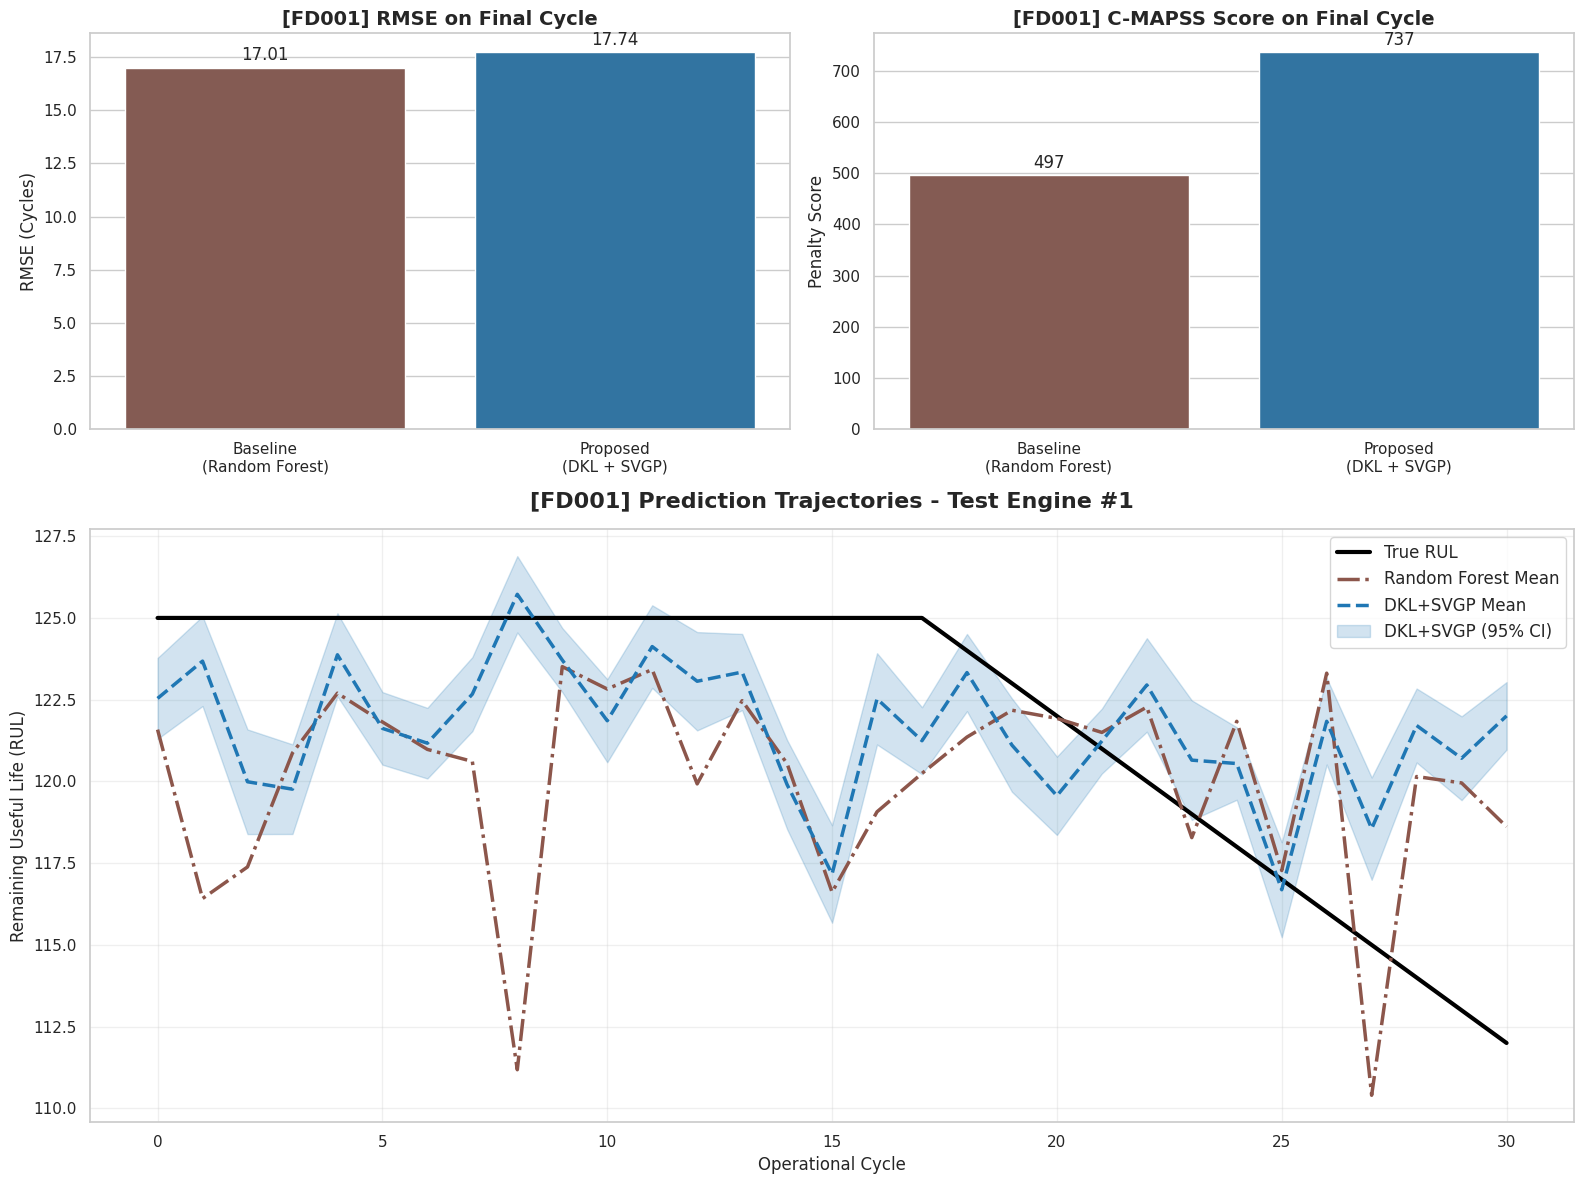


=== RIEPILOGO FINALE METRICHE ===
FD001 -> RF RMSE: 17.01 | DKL RMSE: 17.74


In [10]:
global_results = {}

# Test FD001
global_results['FD001'] = compare_cmapss_dataset('FD001', dkl_epochs=100)

# Test FD002
#global_results['FD002'] = compare_cmapss_dataset('FD002', dkl_epochs=100)

# Test FD003
#global_results['FD003'] = compare_cmapss_dataset('FD003', dkl_epochs=100)

# Test FD004
#global_results['FD004'] = compare_cmapss_dataset('FD004', dkl_epochs=100)


print("\n=== RIEPILOGO FINALE METRICHE ===")
for ds, metrics in global_results.items():
    print(f"{ds} -> RF RMSE: {metrics['rf_rmse']:.2f} | DKL RMSE: {metrics['dkl_rmse']:.2f}")

In [ ]:
# ==============================================================================
# COMPARE: BAYESIAN RIDGE vs DKL + SVGP
# ==============================================================================
import os
import joblib
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import gpytorch


from src.utils.metrics import (
    evaluate_prognostics_model,
    gaussian_nll_from_mean_var,
    crps_gaussian
)

# DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
CHECKPOINTS_DIR = PROJECT_ROOT / 'artifacts' / 'checkpoints'
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

def compare_br_vs_dkl_dataset(dataset_name, dkl_epochs=100, use_saved_model=True):
    print(f"\n\n{'='*90}")
    print(f"🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [{dataset_name}]")
    print(f"{'='*90}")

    
    br_model_path = CHECKPOINTS_DIR / f'br_model_{dataset_name}.pkl'
    dkl_model_path = CHECKPOINTS_DIR / f'dkl_model_{dataset_name}.pth'
    likelihood_path = CHECKPOINTS_DIR / f'likelihood_{dataset_name}.pth'

    # 1. Load data
    df_train = load_cmapss_data(str(DATA_DIR / f'train_{dataset_name}.txt'))
    df_test = load_cmapss_data(str(DATA_DIR / f'test_{dataset_name}.txt'), str(DATA_DIR / f'RUL_{dataset_name}.txt'))

    # 2. Feature Selection (Settings + Sensors)
    candidate_cols = ['setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    variances = df_train[candidate_cols].var()
    dead_cols = variances[variances == 0.0].index.tolist()
    features = [c for c in candidate_cols if c not in dead_cols]

    # 3. RUL Clipping
    MAX_RUL = 125
    df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)
    y_train = df_train['RUL'].values
    y_test_true = df_test['RUL'].values 

    # 4. Standardization (Fit on train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df_train[features].values)
    X_test_scaled = scaler.transform(df_test[features].values)

    # 5. Extracting Last Cycles
    last_cycle_indices = df_test.groupby('unit_nr').tail(1).index
    X_test_last = X_test_scaled[last_cycle_indices]
    y_test_last = y_test_true[last_cycle_indices]
    unit_nrs_last = df_test.iloc[last_cycle_indices]['unit_nr'].values

    # ==========================================
    # --- BAYESIAN RIDGE ---
    # ==========================================
    if use_saved_model and br_model_path.exists():
        print(f"Loading Baseline (Bayesian Ridge) from disk for {dataset_name}...")
        br_model = joblib.load(br_model_path)
    else:
        print("Training Baseline (Bayesian Ridge)...")
        br_model = BayesianRidge()
        br_model.fit(X_train_scaled, y_train)
        joblib.dump(br_model, br_model_path)
        print(f"Bayesian Ridge salvata in {br_model_path.name}")

    # Probabilistic predictive params (last cycle)
    br_preds_last, br_std_last = br_model.predict(X_test_last, return_std=True)
    br_var_last = br_std_last ** 2
    br_lower_last = br_preds_last - (1.96 * br_std_last)
    br_upper_last = br_preds_last + (1.96 * br_std_last)
    
    # Metrics evaluation
    br_metrics = evaluate_prognostics_model(
        br_preds_last, y_test_last, 
        predictive_vars=br_var_last, lower_bounds=br_lower_last, upper_bounds=br_upper_last
    )
    br_nll = gaussian_nll_from_mean_var(br_preds_last, br_var_last, y_test_last)
    br_crps = crps_gaussian(br_preds_last, br_var_last, y_test_last)

    # Trajectory predictions (all cycles)
    br_preds_all, br_std_all = br_model.predict(X_test_scaled, return_std=True)
    br_lower_all = br_preds_all - (1.96 * br_std_all)
    br_upper_all = br_preds_all + (1.96 * br_std_all)

    # ==========================================
    # --- DKL + SVGP ---
    # ==========================================
    if use_saved_model and dkl_model_path.exists() and likelihood_path.exists():
        print(f"🔄 Caricamento Modello Proposto (DKL+SVGP) da disco per {dataset_name}...")
        dkl_model = torch.load(dkl_model_path, weights_only=False, map_location=device)
        likelihood = torch.load(likelihood_path, weights_only=False, map_location=device)
    else:
        print(f"Training Proposed Model (DKL+SVGP - {dkl_epochs} epoche)...")
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

        dkl_model, likelihood = train_dkl_autoencoder(
            train_loader=train_loader, input_dim=len(features), latent_dim=8,
            num_inducing=500, epochs=dkl_epochs, encoder_lr=1e-4,
            decoder_lr=1e-4, gp_lr=1e-2, lambda_recon=0.1, seed=42
        )
        torch.save(dkl_model, dkl_model_path)
        torch.save(likelihood, likelihood_path)
        print(f"Modello DKL+SVGP salvato in {dkl_model_path.name}")

    dkl_model.eval()
    likelihood.eval()

    X_test_last_tensor = torch.tensor(X_test_last, dtype=torch.float32).to(device)
    X_test_all_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # Last cycle predictions
        pred_dist_last = likelihood(dkl_model(X_test_last_tensor))
        dkl_preds_last = pred_dist_last.mean.cpu().numpy()
        dkl_var_last = pred_dist_last.variance.cpu().numpy()
        lower_last, upper_last = pred_dist_last.confidence_region()
        dkl_lower_last = lower_last.cpu().numpy()
        dkl_upper_last = upper_last.cpu().numpy()
        
        # Metrics evaluation
        dkl_metrics = evaluate_prognostics_model(
            dkl_preds_last, y_test_last, 
            predictive_vars=dkl_var_last, lower_bounds=dkl_lower_last, upper_bounds=dkl_upper_last
        )
        dkl_nll = gaussian_nll_from_mean_var(dkl_preds_last, dkl_var_last, y_test_last)
        dkl_crps = crps_gaussian(dkl_preds_last, dkl_var_last, y_test_last)

        # Trajectory predictions (all cycles)
        pred_dist_all = likelihood(dkl_model(X_test_all_tensor))
        dkl_preds_all = pred_dist_all.mean.cpu().numpy()
        lower_all, upper_all = pred_dist_all.confidence_region()
        dkl_lower_all = lower_all.cpu().numpy()
        dkl_upper_all = upper_all.cpu().numpy()


    print("\n --- STIME PUNTUALI E INTERVALLI DI CONFIDENZA (95%) SUI CICLI FINALI (Prime 5 UUT) ---")
    header = f"{'Unit ID':<8} | {'True RUL':<8} | {'BR Pred':<8} | {'Intervallo Bayesian Ridge':<32} | {'DKL Pred':<8} | {'Intervallo DKL+SVGP':<32}"
    print(header)
    print("-" * len(header))
    for i in range(min(5, len(unit_nrs_last))):
        br_width = br_upper_last[i] - br_lower_last[i]
        dkl_width = dkl_upper_last[i] - dkl_lower_last[i]
        
        br_str = f"[{br_lower_last[i]:.1f}, {br_upper_last[i]:.1f}] (w:{br_width:.1f})"
        dkl_str = f"[{dkl_lower_last[i]:.1f}, {dkl_upper_last[i]:.1f}] (w:{dkl_width:.1f})"
        
        print(f"UUT #{unit_nrs_last[i]:<4} | {y_test_last[i]:<8.0f} | {br_preds_last[i]:<8.1f} | {br_str:<32} | {dkl_preds_last[i]:<8.1f} | {dkl_str:<32}")
    print("-" * len(header))

    # Extrarre i valori scalari pronti per il report e per correggere il bug KeyError
    br_rmse = br_metrics['RMSE (Root Mean Squared Error)']
    dkl_rmse = dkl_metrics['RMSE (Root Mean Squared Error)']
    br_score_val = br_metrics['PHM08 Asymmetric Score (Lower is better)']
    dkl_score_val = dkl_metrics['PHM08 Asymmetric Score (Lower is better)']

    # ==========================================
    # --- REPORT DI TUTTE LE METRICHE ---
    # ==========================================
    print("\n --- REPORT METRICHE FINALI COMPLETO ---")
    print(f"{'Metrica':<45} | {'Bayesian Ridge':<15} | {'DKL+SVGP':<15}")
    print("-" * 81)
    print(f"{'RMSE (Cicli) [↓]':<45} | {br_rmse:<15.2f} | {dkl_rmse:<15.2f}")
    print(f"{'MAE (Cicli) [↓]':<45} | {br_metrics['MAE (Mean Absolute Error)']:<15.2f} | {dkl_metrics['MAE (Mean Absolute Error)']:<15.2f}")
    print(f"{'R-Squared (R2) [↑]':<45} | {br_metrics['R2 (Higher is better)']:<15.3f} | {dkl_metrics['R2 (Higher is better)']:<15.3f}")
    print(f"{'C-MAPSS Score [↓]':<45} | {br_score_val:<15.0f} | {dkl_score_val:<15.0f}")
    print(f"{'Fleet Correlation Metric [↑]':<45} | {br_metrics['Fleet Correlation Metric (Higher is better)']:<15.3f} | {dkl_metrics['Fleet Correlation Metric (Higher is better)']:<15.3f}")
    print(f"{'Perfect Predictions (d = 0)':<45} | {br_metrics['Perfect Predictions (d = 0)']:<15} | {dkl_metrics['Perfect Predictions (d = 0)']:<15}")
    print(f"{'Early Predictions (d < 0, Sicuri)':<45} | {br_metrics['Early Predictions (d < 0, Safer)']:<15} | {dkl_metrics['Early Predictions (d < 0, Safer)']:<15}")
    print(f"{'Late Predictions (d > 0, Pericolosi)':<45} | {br_metrics['Late Predictions (d > 0, Dangerous)']:<15} | {dkl_metrics['Late Predictions (d > 0, Dangerous)']:<15}")
    print("-" * 81)
    print(f"{'Negative Log-Likelihood (NLL) [↓]':<45} | {br_nll:<15.3f} | {dkl_nll:<15.3f}")
    print(f"{'Continuous Ranked Prob. Score (CRPS) [↓]':<45} | {br_crps:<15.3f} | {dkl_crps:<15.3f}")
    print(f"{'PICP (Prediction Interval Coverage 95%)':<45} | {br_metrics.get('picp_95', 0)*100:<14.1f}% | {dkl_metrics.get('picp_95', 0)*100:<14.1f}%")
    print(f"{'Avg Prediction Interval Width [↓]':<45} | {br_metrics.get('avg_interval_width_95', 0):<15.2f} | {dkl_metrics.get('avg_interval_width_95', 0):<15.2f}")
    print(f"{'Avg Predictive Variance':<45} | {br_metrics.get('avg_pred_variance', 0):<15.2f} | {dkl_metrics.get('avg_pred_variance', 0):<15.2f}")
    print("-" * 81)

    # ==========================================================================
    # --- GRIGLIA DEI GRAFICI AVANZATI ---
    # ==========================================================================
    fig = plt.figure(figsize=(18, 18))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.5])

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_score = fig.add_subplot(gs[0, 1])
    ax_crps = fig.add_subplot(gs[1, 0])
    ax_picp = fig.add_subplot(gs[1, 1])
    ax_traj = fig.add_subplot(gs[2, :]) 

    models_labels = ['Bayesian\nRidge', 'Proposed\n(DKL + SVGP)']
    palette = ['#2ca02c', '#1f77b4'] 

    # Plot 1: RMSE Barplot
    sns.barplot(x=models_labels, y=[br_rmse, dkl_rmse], ax=ax_rmse, hue=models_labels, palette=palette, legend=False)
    ax_rmse.set_title(f'[{dataset_name}] RMSE on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_rmse.set_ylabel('RMSE (Cycles)')
    for i, v in enumerate([br_rmse, dkl_rmse]):
        ax_rmse.text(i, v + (max(br_rmse, dkl_rmse)*0.02), f"{v:.2f}", ha='center', fontsize=11)

    # Plot 2: C-MAPSS Score Barplot
    sns.barplot(x=models_labels, y=[br_score_val, dkl_score_val], ax=ax_score, hue=models_labels, palette=palette, legend=False)
    ax_score.set_title(f'[{dataset_name}] C-MAPSS Score on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_score.set_ylabel('C-MAPSS Penalty Score')
    for i, v in enumerate([br_score_val, dkl_score_val]):
        ax_score.text(i, v + (max(br_score_val, dkl_score_val)*0.02), f"{v:,.0f}", ha='center', fontsize=11)

    # Plot 3: CRPS Barplot
    sns.barplot(x=models_labels, y=[br_crps, dkl_crps], ax=ax_crps, hue=models_labels, palette=palette, legend=False)
    ax_crps.set_title(f'[{dataset_name}] CRPS on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_crps.set_ylabel('CRPS Score')
    for i, v in enumerate([br_crps, dkl_crps]):
        ax_crps.text(i, v + (max(br_crps, dkl_crps)*0.02), f"{v:.3f}", ha='center', fontsize=11)

    # Plot 4: PICP Coverage Barplot (uncertainty calibration)
    br_picp = br_metrics.get('picp_95', 0)
    dkl_picp = dkl_metrics.get('picp_95', 0)
    sns.barplot(x=models_labels, y=[br_picp, dkl_picp], ax=ax_picp, hue=models_labels, palette=palette, legend=False)
    ax_picp.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Target Nominal (95%)')
    ax_picp.set_title(f'[{dataset_name}] Prediction Interval Coverage (Target: 95%)', fontsize=12, fontweight='bold')
    ax_picp.set_ylabel('Coverage Probability')
    ax_picp.set_ylim(0, 1.1)
    ax_picp.legend(loc='lower right')
    for i, v in enumerate([br_picp, dkl_picp]):
        ax_picp.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=11)

    # Plot 5: Trajectory of Engine
    first_engine_id = df_test['unit_nr'].unique()[0]
    eng_indices = df_test[df_test['unit_nr'] == first_engine_id].index
    y_true_eng = y_test_true[eng_indices]
    cycles = range(len(y_true_eng))

    ax_traj.plot(cycles, y_true_eng, label='True RUL', color='black', linewidth=3)
    
    ax_traj.plot(cycles, br_preds_all[eng_indices], label='Bayesian Ridge Mean', color='#2ca02c', linestyle='-.', linewidth=2.5)
    ax_traj.fill_between(cycles, br_lower_all[eng_indices], br_upper_all[eng_indices], color='#2ca02c', alpha=0.15, label='Bayesian Ridge (95% CI)')
    
    ax_traj.plot(cycles, dkl_preds_all[eng_indices], label='DKL+SVGP Mean', color='#1f77b4', linestyle='--', linewidth=2.5)
    ax_traj.fill_between(cycles, dkl_lower_all[eng_indices], dkl_upper_all[eng_indices], color='#1f77b4', alpha=0.2, label='DKL+SVGP (95% CI)')

    ax_traj.set_title(f'[{dataset_name}] Bayesian Ridge vs DKL+SVGP - Test Engine #{first_engine_id}', fontsize=16, fontweight='bold', pad=15)
    ax_traj.set_xlabel('Operational Cycle', fontsize=12)
    ax_traj.set_ylabel('Remaining Useful Life (RUL)', fontsize=12)
    ax_traj.legend(fontsize=12, loc='upper right')
    ax_traj.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'br_rmse': br_rmse, 
        'dkl_rmse': dkl_rmse, 
        'br_score': br_score_val, 
        'dkl_score': dkl_score_val
    }



🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD001]
🔄 Caricamento Baseline (Bayesian Ridge) da disco per FD001...
🔄 Caricamento Modello Proposto (DKL+SVGP) da disco per FD001...

🔍 --- STIME PUNTUALI E INTERVALLI DI CONFIDENZA (95%) SUI CICLI FINALI (Prime 5 UUT) ---
Unit ID  | True RUL | BR Pred  | Intervallo Bayesian Ridge        | DKL Pred | Intervallo DKL+SVGP             
---------------------------------------------------------------------------------------------------------------
UUT #1    | 112      | 121.1    | [79.0, 163.2] (w:84.2)           | 121.3    | [120.3, 122.3] (w:2.0)          
UUT #2    | 98       | 98.8     | [56.7, 140.9] (w:84.2)           | 116.0    | [114.2, 117.8] (w:3.6)          
UUT #3    | 69       | 73.2     | [31.1, 115.3] (w:84.2)           | 74.2     | [73.0, 75.4] (w:2.4)            
UUT #4    | 82       | 81.0     | [38.9, 123.1] (w:84.2)           | 95.2     | [94.1, 96.3] (w:2.2)            
UUT #5    | 91       | 90.0     | [47

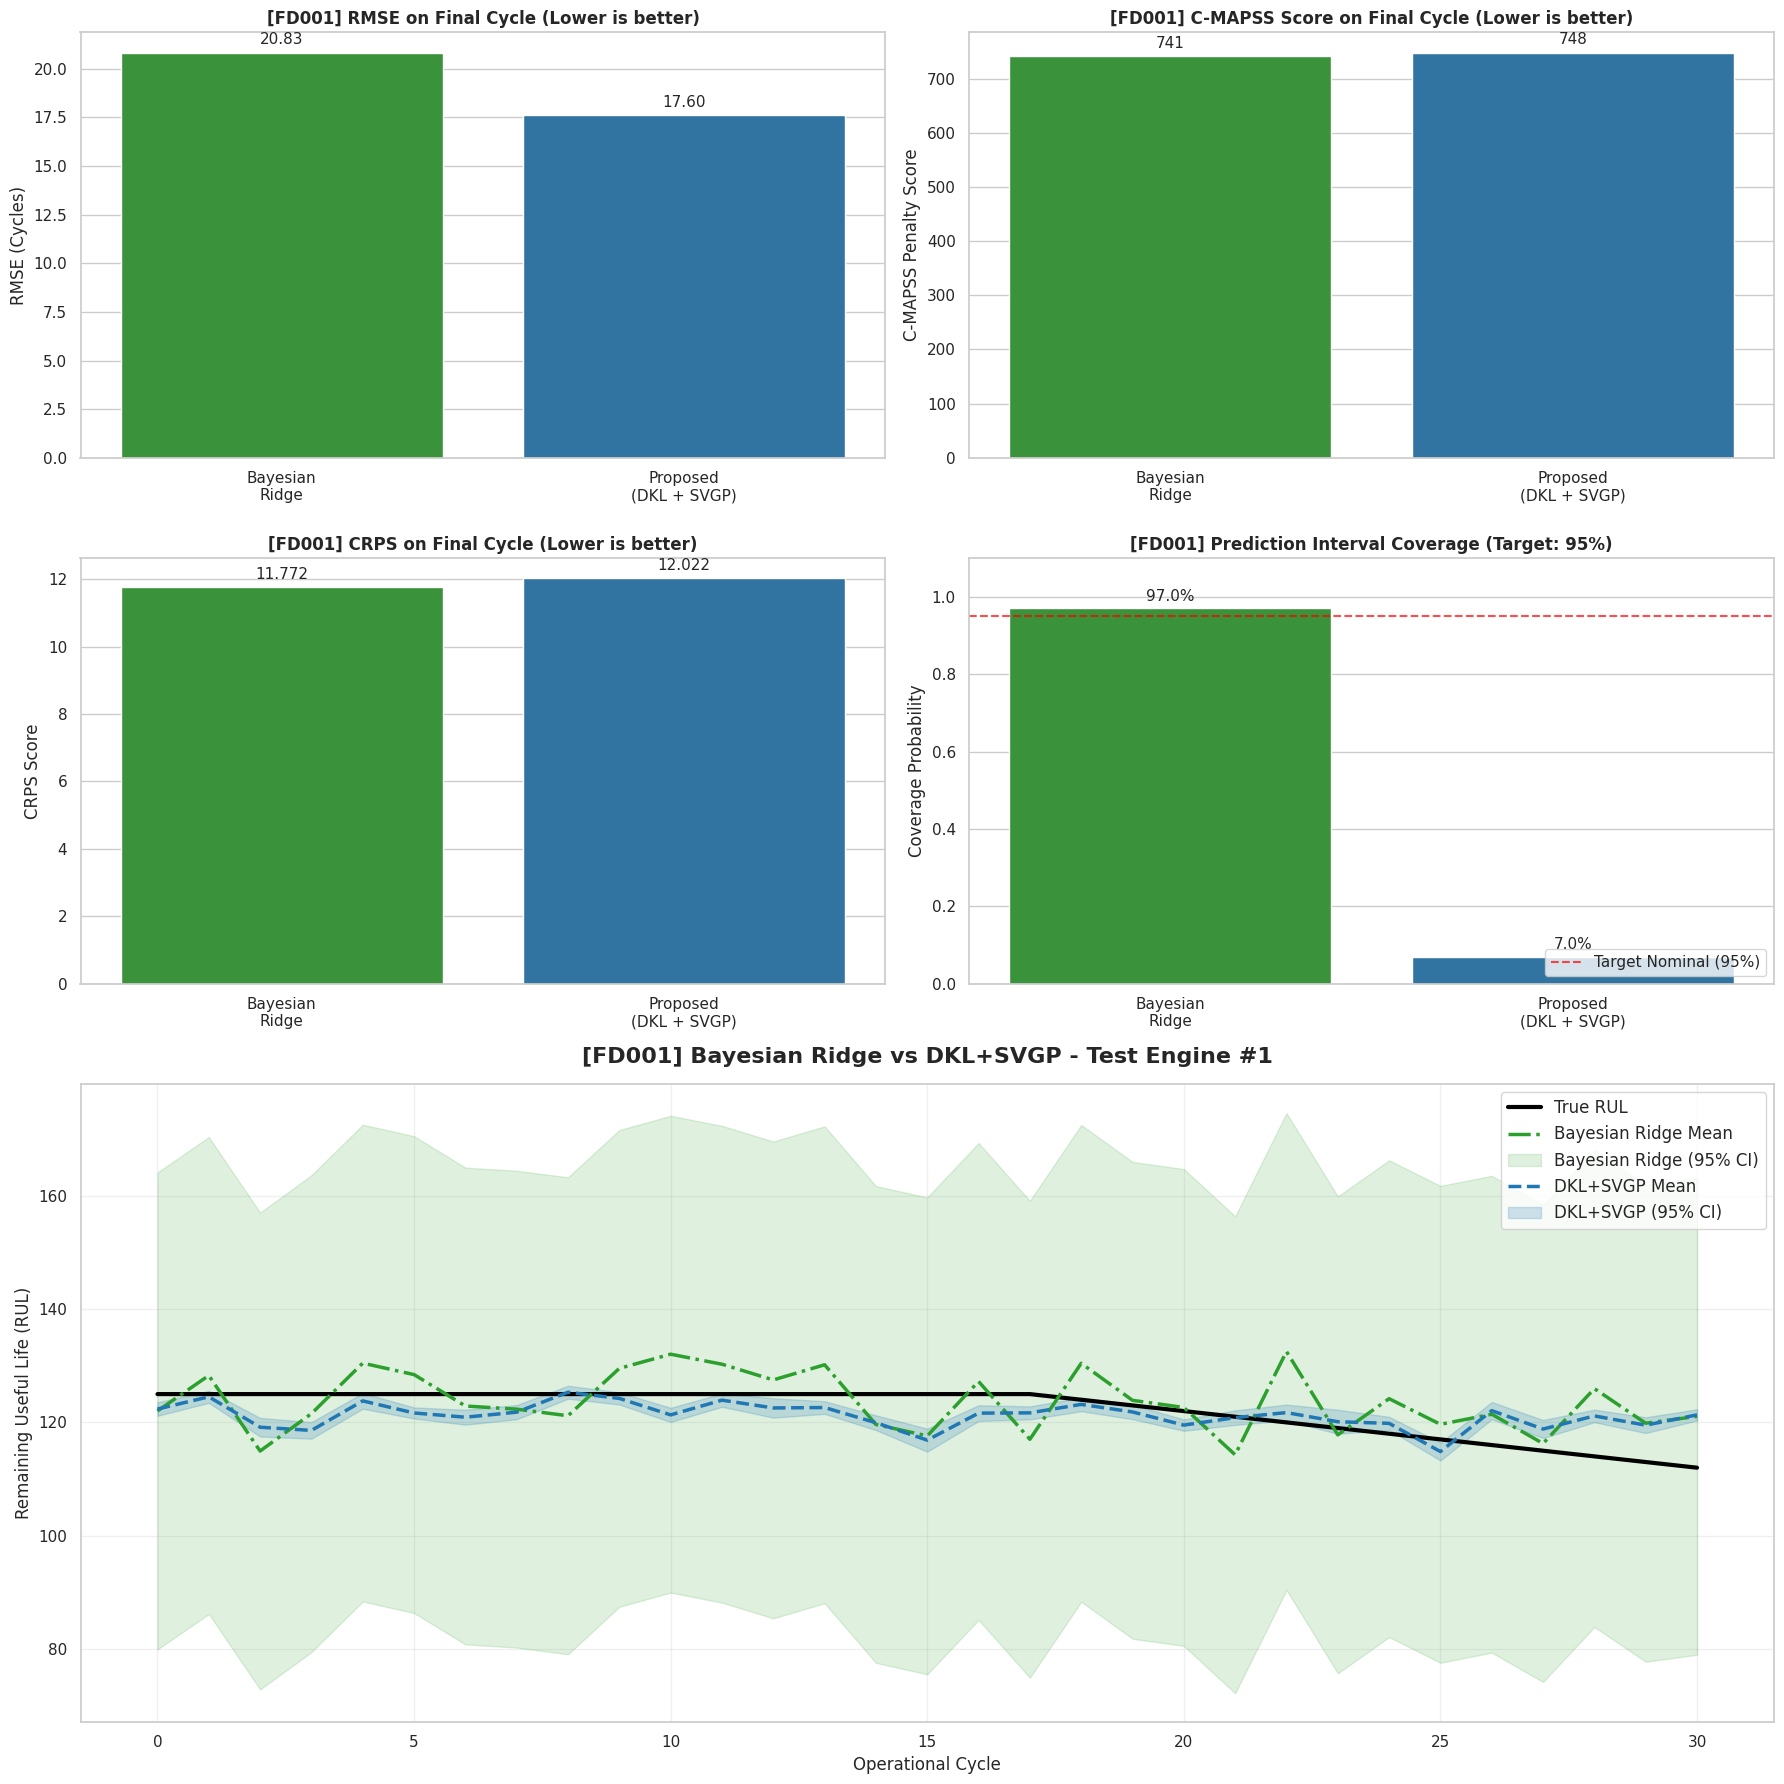


=== RIEPILOGO FINALE METRICHE (BAYESIAN RIDGE vs DKL) ===
FD001 -> BR RMSE: 20.83 | DKL RMSE: 17.60


In [ ]:
br_dkl_results = {}

# Test FD001
br_dkl_results['FD001'] = compare_br_vs_dkl_dataset('FD001', dkl_epochs=100)



🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD002]
📈 Training Baseline (Bayesian Ridge)...
💾 Bayesian Ridge salvata in br_model_FD002.pkl
🧠 Training Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | ELBO Loss: 176354.2565 | Recon Loss: 0.8516
Epoch 02 | ELBO Loss: 59847.0793 | Recon Loss: 0.2428
Epoch 03 | ELBO Loss: 34179.3103 | Recon Loss: 0.3025
Epoch 04 | ELBO Loss: 25938.8851 | Recon Loss: 0.1640
Epoch 05 | ELBO Loss: 20225.0795 | Recon Loss: 0.1225
Epoch 06 | ELBO Loss: 18402.8673 | Recon Loss: 0.0907
Epoch 07 | ELBO Loss: 16936.8312 | Recon Loss: 0.0707
Epoch 08 | ELBO Loss: 15709.1803 | Recon Loss: 0.0549
Epoch 09 | ELBO Loss: 14157.8403 | Recon Loss: 0.0423
Epoch 10 | ELBO Loss: 12810.7171 | Recon Loss: 0.0328
Epoch 11 | ELBO Loss: 11845.5431 | Recon Loss: 0.0325
Epoch 12 | ELBO Loss: 11048.4052 | Recon Loss: 0.0330
Epoch 13 | ELBO Loss: 10379.0148 | Recon Loss: 0.0306
Epoch 14 | ELBO Loss: 9666

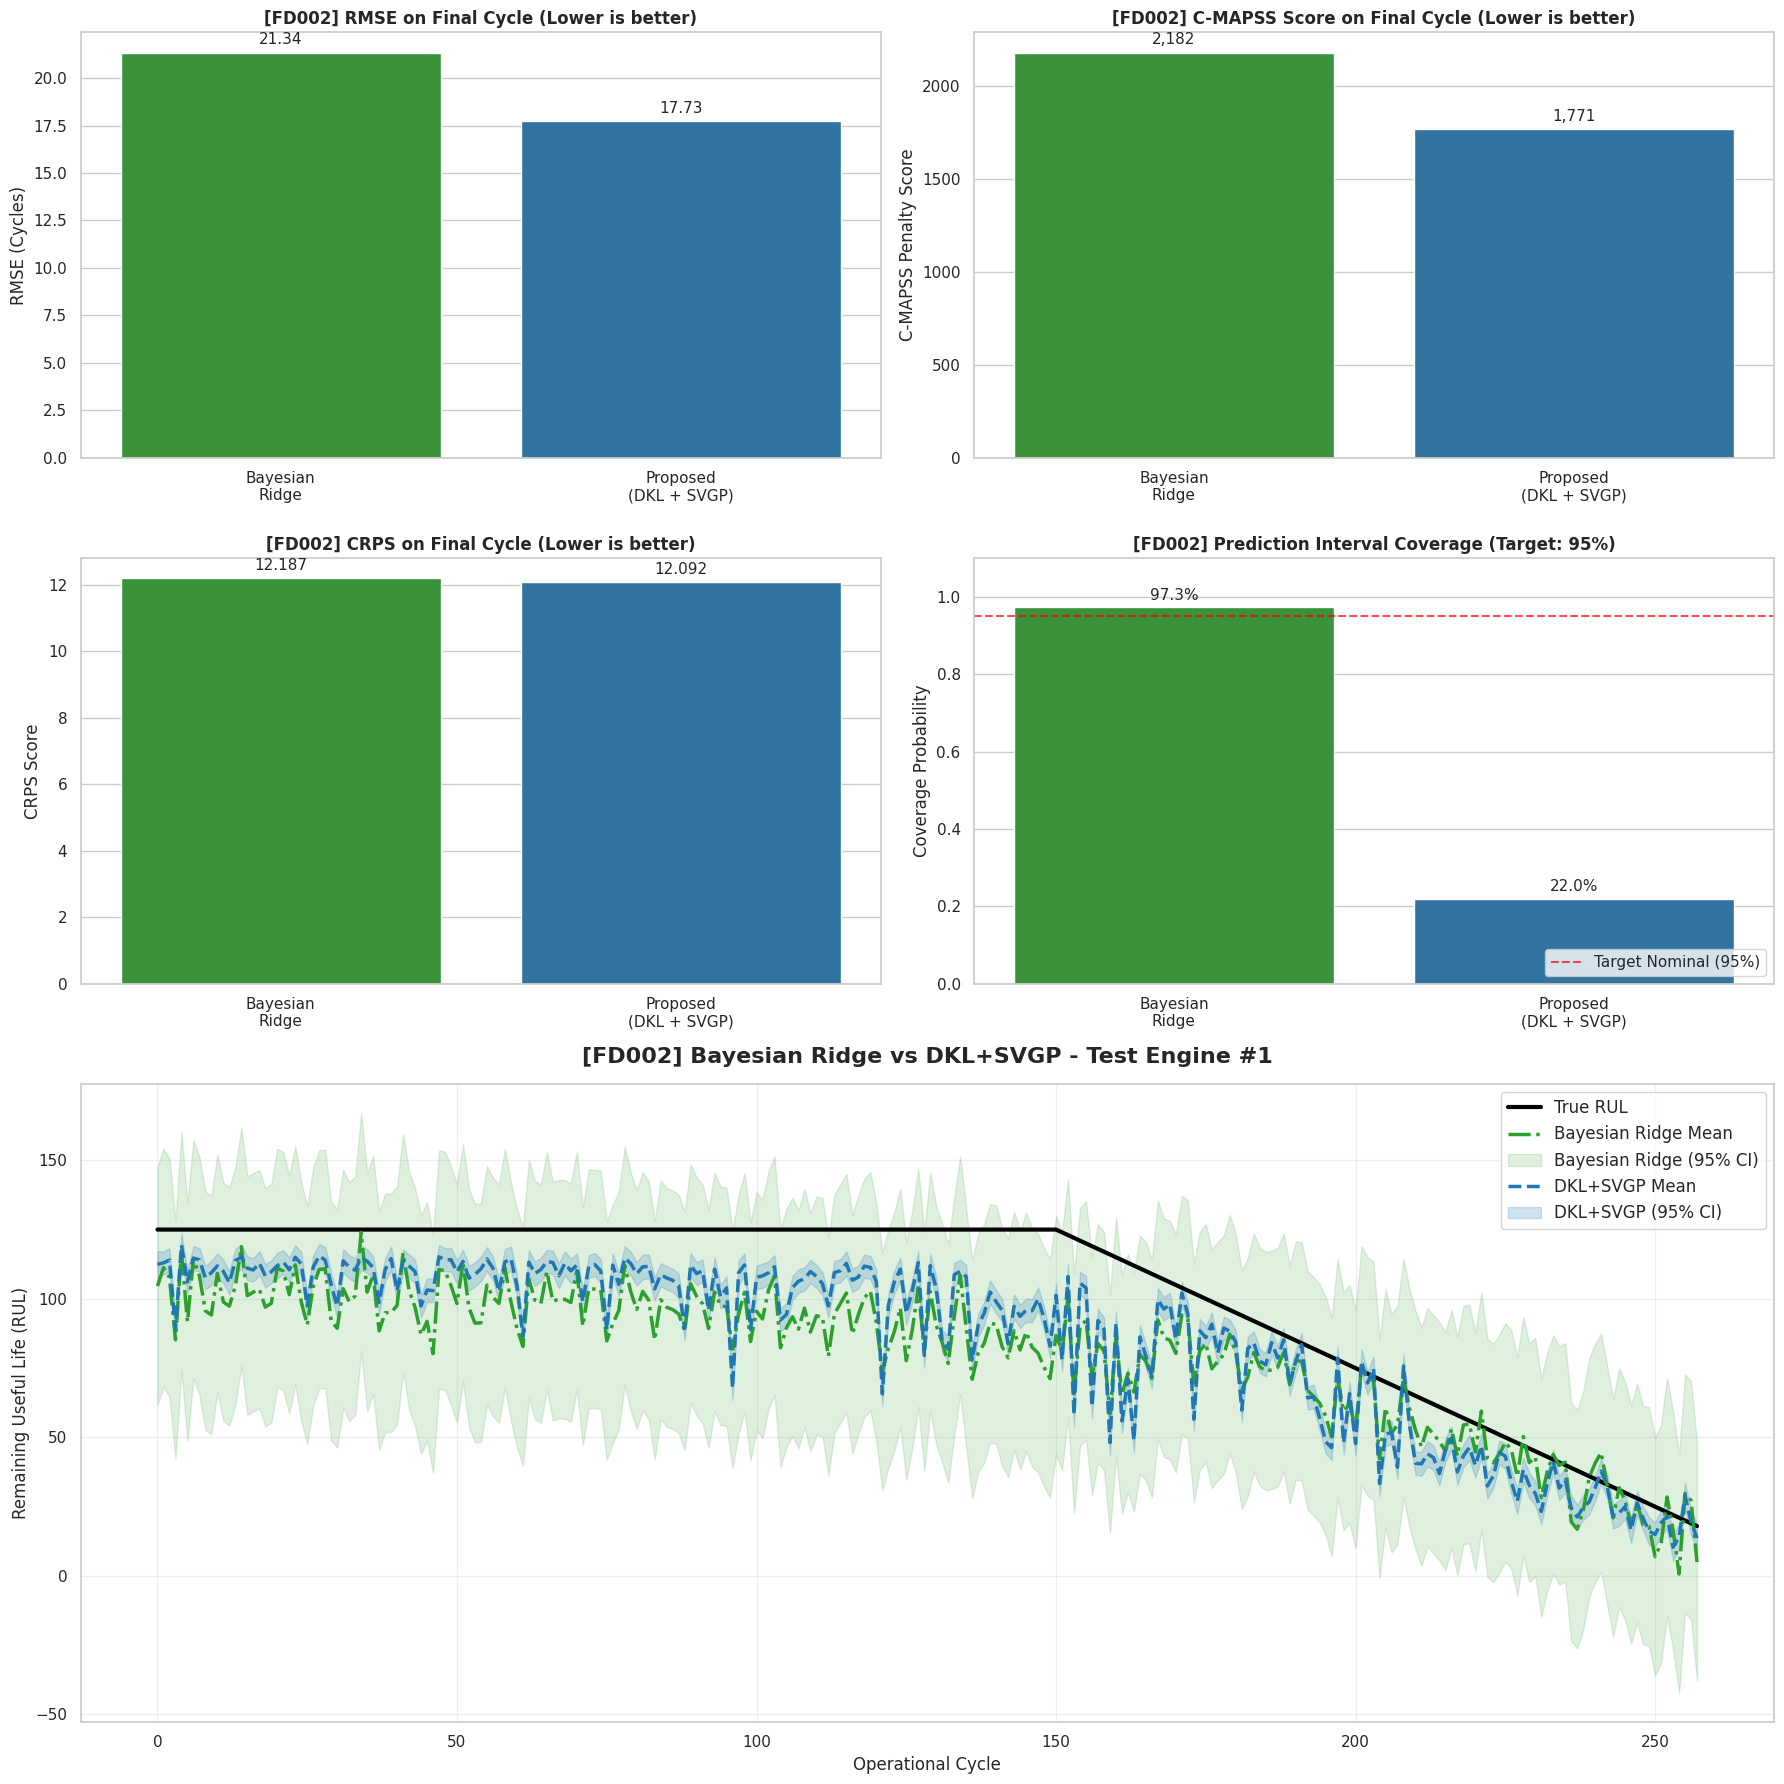


=== RIEPILOGO FINALE METRICHE (BAYESIAN RIDGE vs DKL) ===
FD001 -> BR RMSE: 20.83 | DKL RMSE: 17.60
FD002 -> BR RMSE: 21.34 | DKL RMSE: 17.73


In [ ]:
# Test FD002
br_dkl_results['FD002'] = compare_br_vs_dkl_dataset('FD002', dkl_epochs=100)



🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD003]
📈 Training Baseline (Bayesian Ridge)...
💾 Bayesian Ridge salvata in br_model_FD003.pkl
🧠 Training Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | ELBO Loss: 327728.9221 | Recon Loss: 0.8445
Epoch 02 | ELBO Loss: 33470.1836 | Recon Loss: 0.6129
Epoch 03 | ELBO Loss: 16256.7111 | Recon Loss: 0.4973
Epoch 04 | ELBO Loss: 14504.5218 | Recon Loss: 0.4112
Epoch 05 | ELBO Loss: 14017.9766 | Recon Loss: 0.3453
Epoch 06 | ELBO Loss: 13248.4020 | Recon Loss: 0.3093
Epoch 07 | ELBO Loss: 12854.3276 | Recon Loss: 0.2867
Epoch 08 | ELBO Loss: 12454.1178 | Recon Loss: 0.2689
Epoch 09 | ELBO Loss: 12167.5567 | Recon Loss: 0.2554
Epoch 10 | ELBO Loss: 11885.7089 | Recon Loss: 0.2449
Epoch 11 | ELBO Loss: 11550.8725 | Recon Loss: 0.2353
Epoch 12 | ELBO Loss: 11366.1108 | Recon Loss: 0.2281
Epoch 13 | ELBO Loss: 11153.8552 | Recon Loss: 0.2246
Epoch 14 | ELBO Loss: 1081

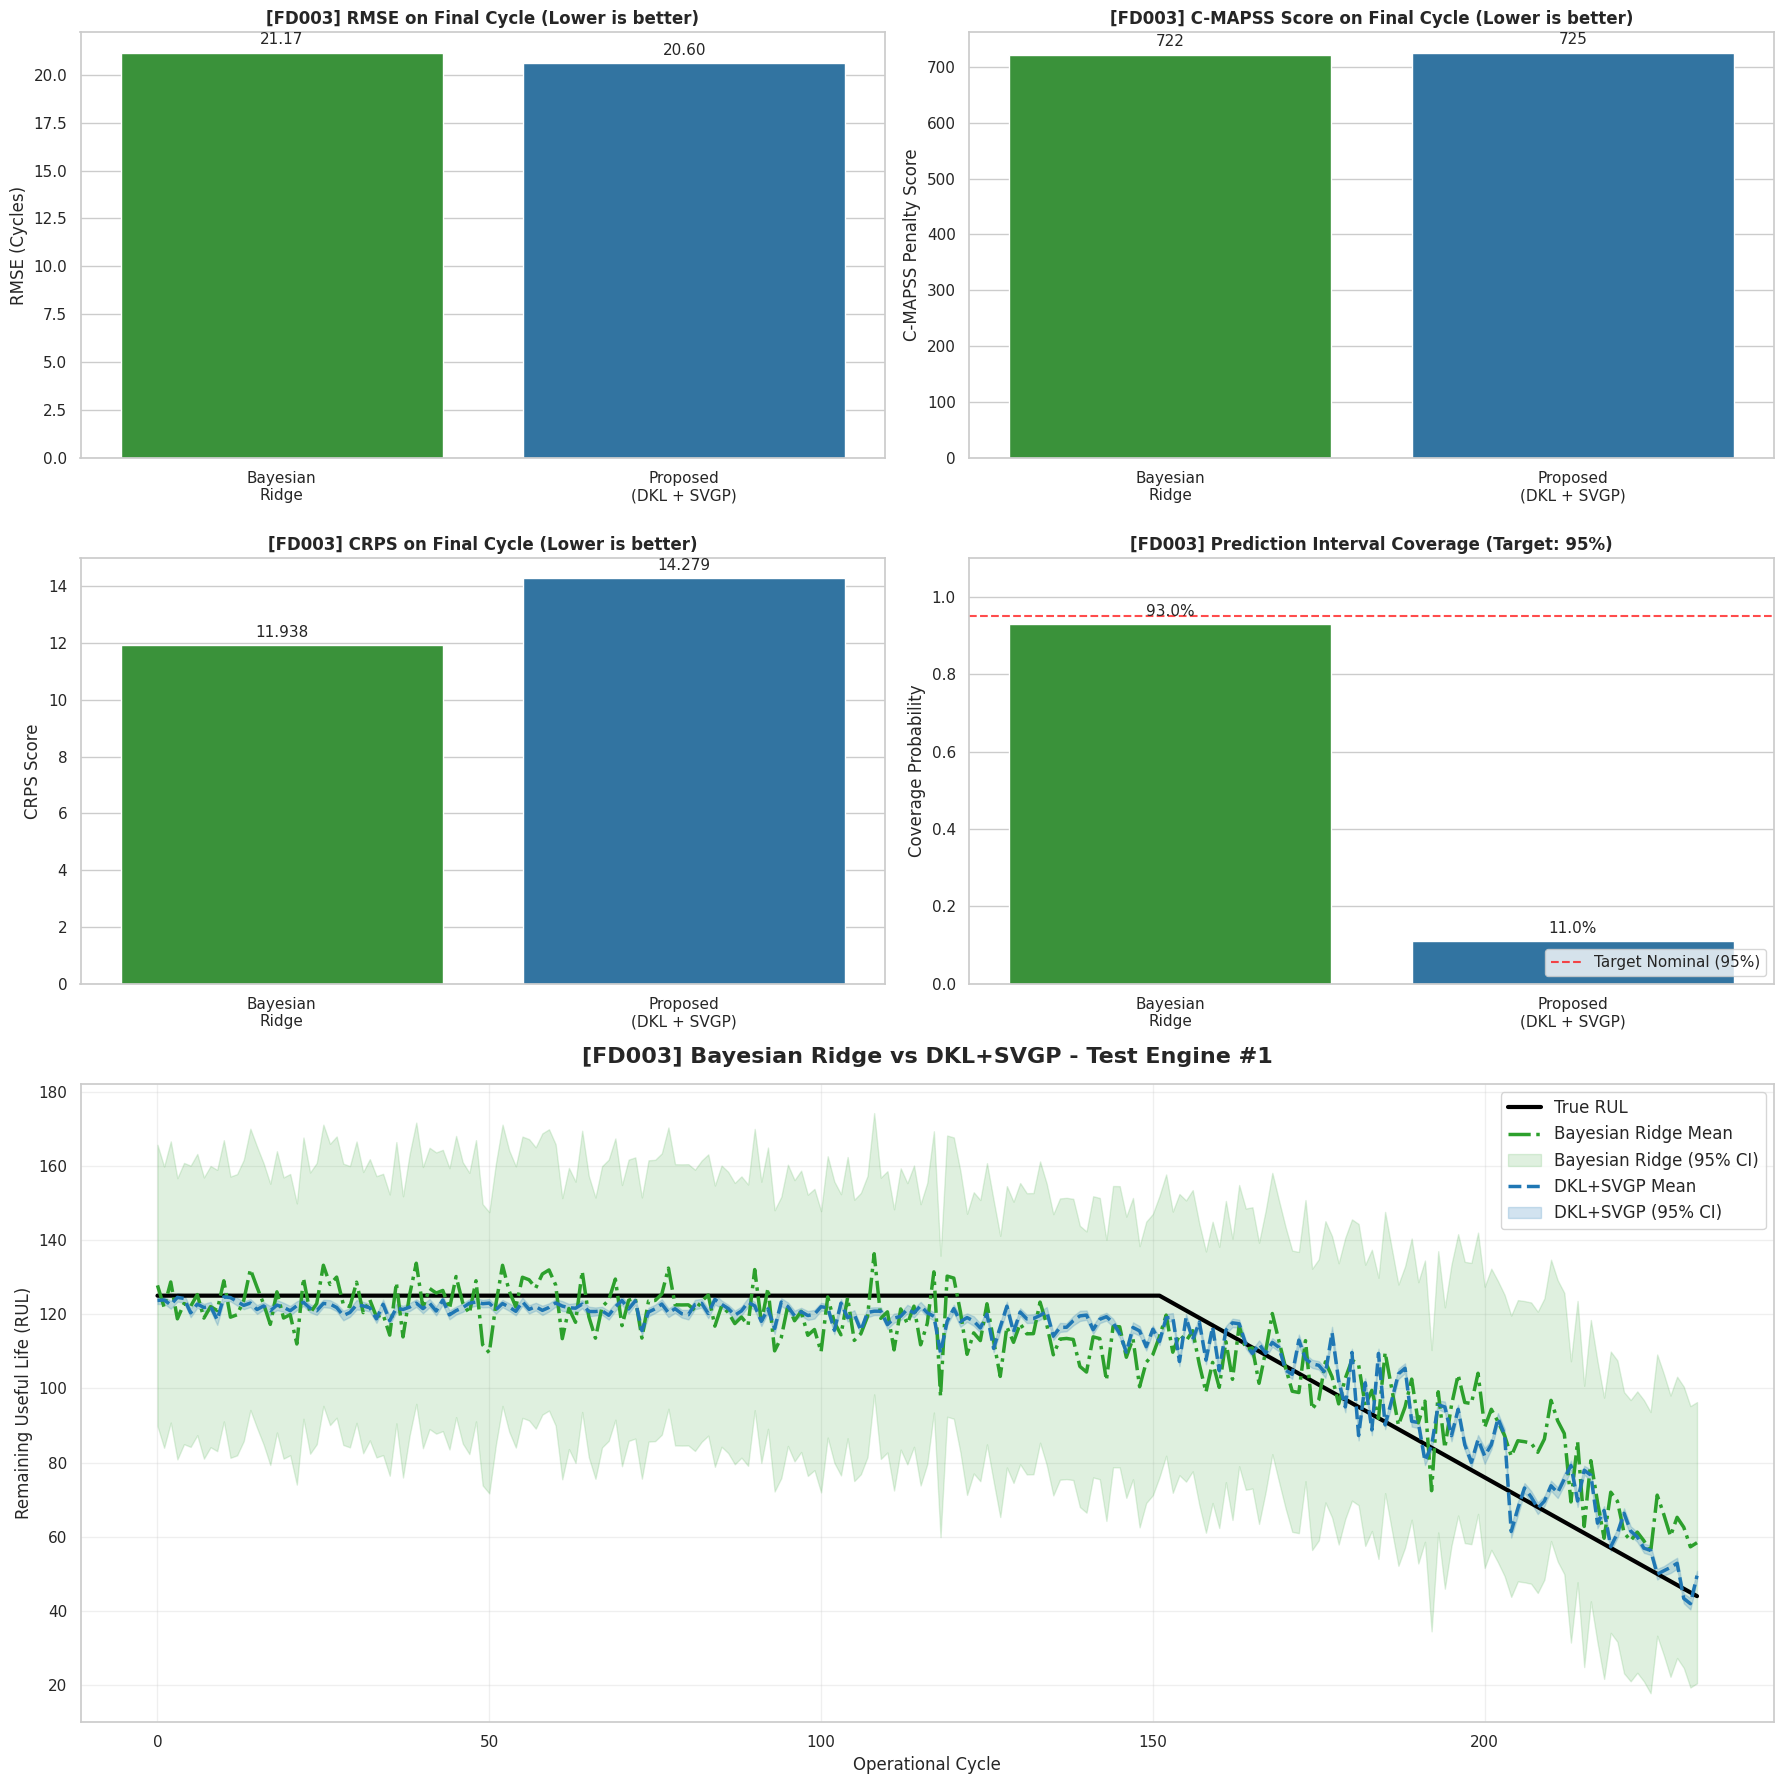


=== RIEPILOGO FINALE METRICHE (BAYESIAN RIDGE vs DKL) ===
FD001 -> BR RMSE: 20.83 | DKL RMSE: 17.60
FD002 -> BR RMSE: 21.34 | DKL RMSE: 17.73
FD004 -> BR RMSE: 24.46 | DKL RMSE: 20.82
FD003 -> BR RMSE: 21.17 | DKL RMSE: 20.60


In [ ]:
# Test FD003
br_dkl_results['FD003'] = compare_br_vs_dkl_dataset('FD003', dkl_epochs=100)



🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD004]
📈 Training Baseline (Bayesian Ridge)...
💾 Bayesian Ridge salvata in br_model_FD004.pkl
🧠 Training Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | ELBO Loss: 176056.4931 | Recon Loss: 0.7513
Epoch 02 | ELBO Loss: 50891.1488 | Recon Loss: 0.1541
Epoch 03 | ELBO Loss: 31334.3103 | Recon Loss: 0.2134
Epoch 04 | ELBO Loss: 23195.6731 | Recon Loss: 0.1068
Epoch 05 | ELBO Loss: 19939.8604 | Recon Loss: 0.0627
Epoch 06 | ELBO Loss: 17628.5983 | Recon Loss: 0.0647
Epoch 07 | ELBO Loss: 15640.2898 | Recon Loss: 0.0701
Epoch 08 | ELBO Loss: 14494.6758 | Recon Loss: 0.0725
Epoch 09 | ELBO Loss: 12773.3169 | Recon Loss: 0.0936
Epoch 10 | ELBO Loss: 11889.1803 | Recon Loss: 0.0742
Epoch 11 | ELBO Loss: 10742.1705 | Recon Loss: 0.0561
Epoch 12 | ELBO Loss: 9902.0850 | Recon Loss: 0.0726
Epoch 13 | ELBO Loss: 9302.7472 | Recon Loss: 0.1165
Epoch 14 | ELBO Loss: 8417.2

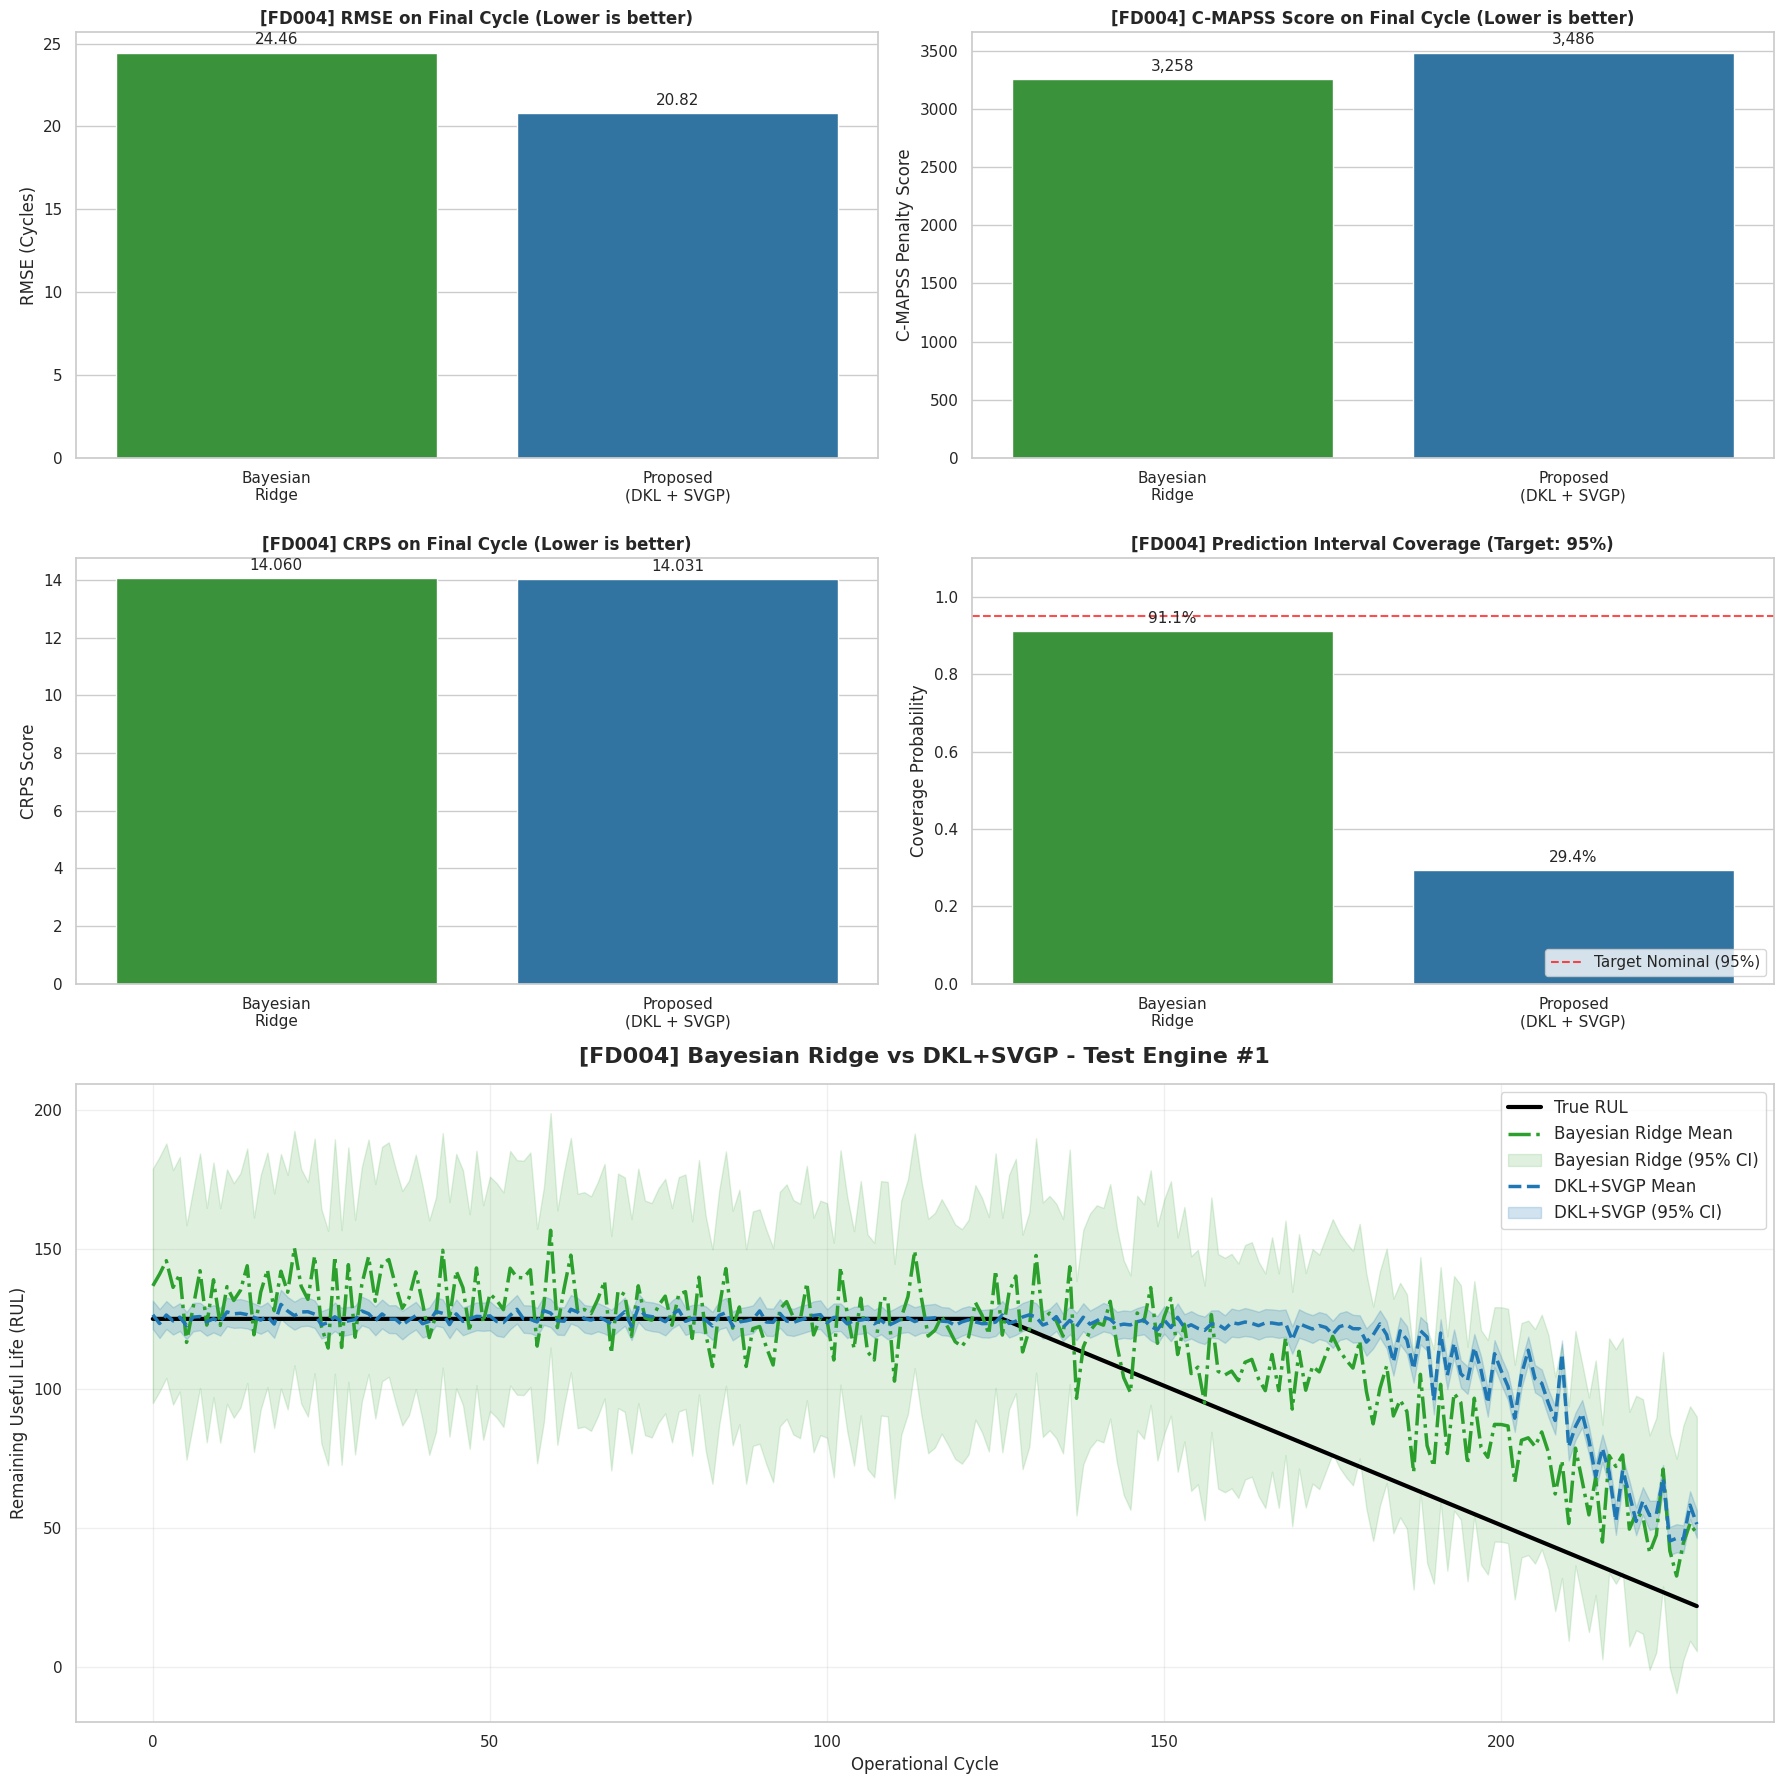


=== RIEPILOGO FINALE METRICHE (BAYESIAN RIDGE vs DKL) ===
FD001 -> BR RMSE: 20.83 | DKL RMSE: 17.60
FD002 -> BR RMSE: 21.34 | DKL RMSE: 17.73
FD004 -> BR RMSE: 24.46 | DKL RMSE: 20.82


In [ ]:
# Test FD004
br_dkl_results['FD004'] = compare_br_vs_dkl_dataset('FD004', dkl_epochs=100)

print("\n=== SUMMARY METRIC COMPARISON: BAYESIAN RIDGE vs DKL) ===")
for ds, metrics in br_dkl_results.items():
    print(f"{ds} -> BR RMSE: {metrics['br_rmse']:.2f} | DKL RMSE: {metrics['dkl_rmse']:.2f}")